# Import Libraries

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Import Dataset

In [83]:
df = pd.read_csv(r'C:\Users\angge\Downloads\Membangun Sistem Machine Learning\SMSML_Angger-Hanggara\Membangun_model\Churn_preprocessing\Churn_Modelling.csv', encoding='latin-1')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Data Wrangling

In [84]:
# Checking for information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [85]:
# Checking for missing values in the dataset
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [86]:
# Checking for duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

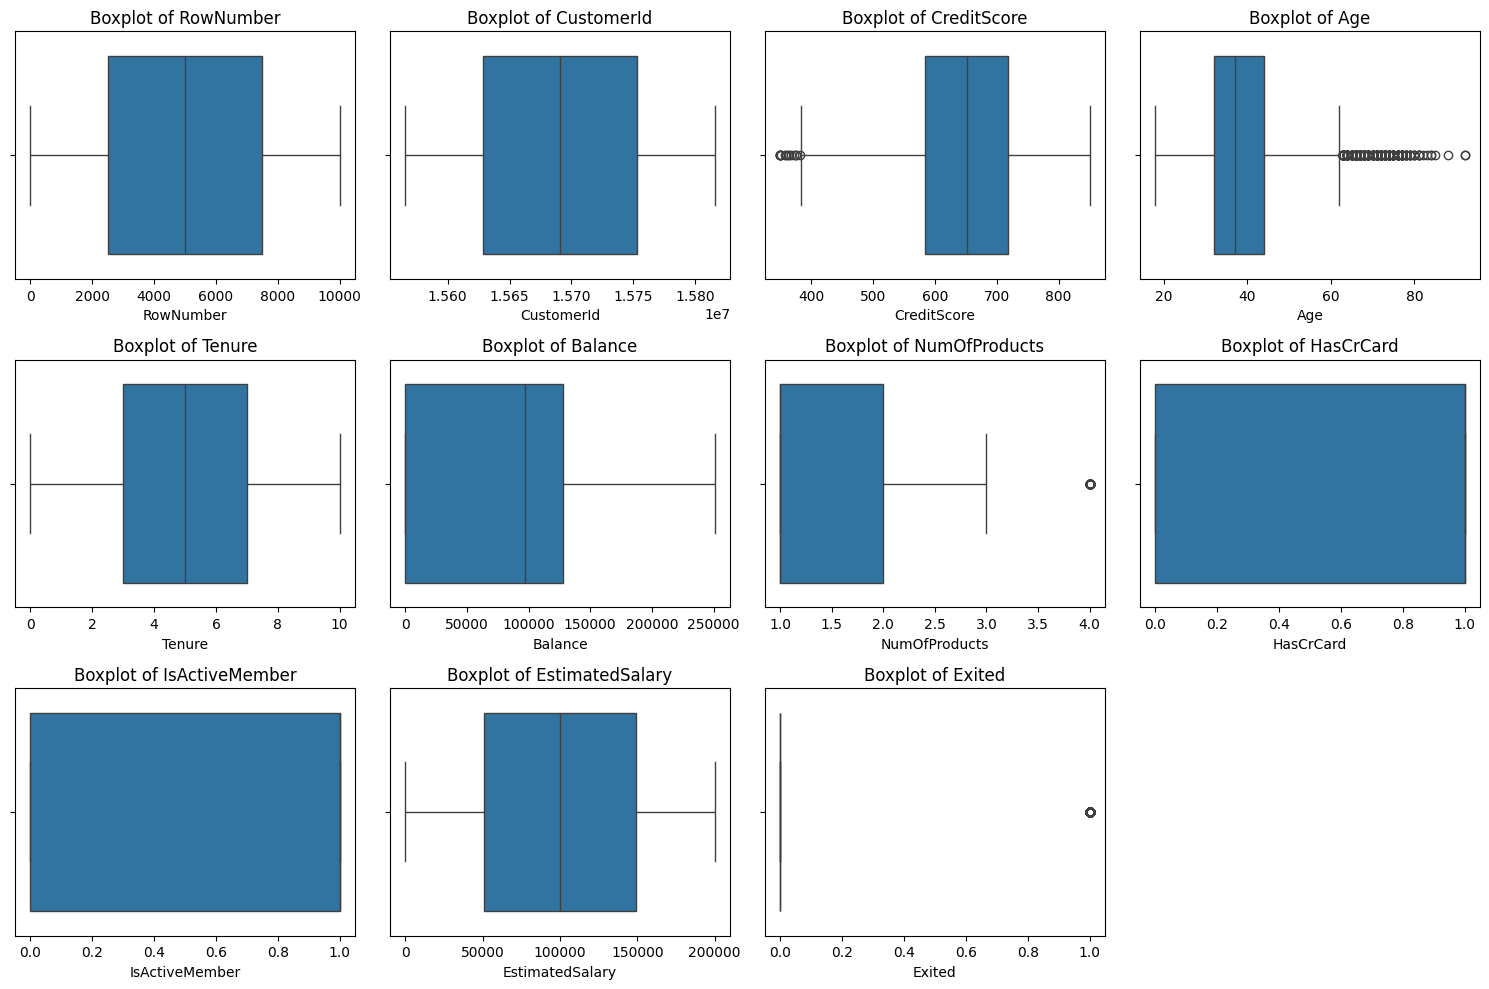

In [87]:
# Find the outliers in the dataset using boxplot
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

# Exploratory Data Analysis

## Univariate Analysis

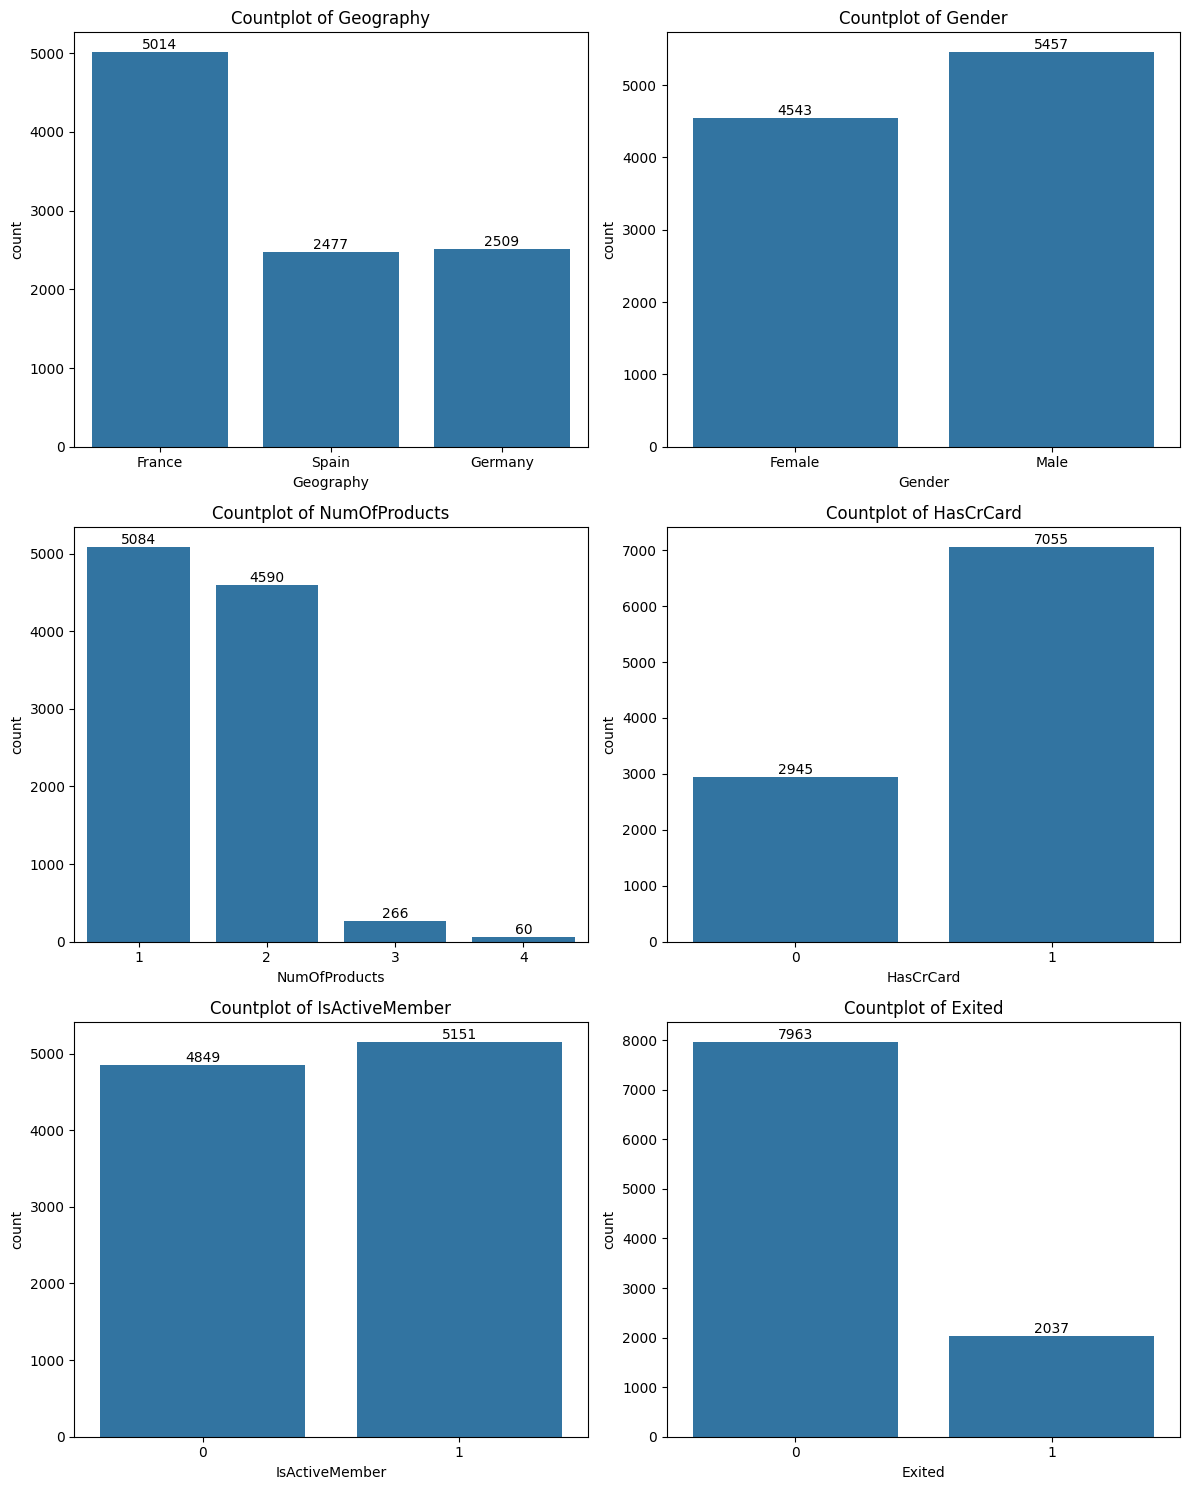

In [88]:
# univariate analysis for categorical variables
geo_count = df['Geography'].value_counts
gen_count = df['Gender'].value_counts
num_count = df['NumOfProducts'].value_counts
HasCrCard_count = df['HasCrCard'].value_counts
is_active_count = df['IsActiveMember'].value_counts
exited_count = df['Exited'].value_counts

plt.figure(figsize=(12, 15))
plt.subplot(3, 2, 1)
ax1 = sns.countplot(x=df['Geography'])
ax1.bar_label(ax1.containers[0])
plt.title('Countplot of Geography')
plt.subplot(3, 2, 2)
ax2 = sns.countplot(x=df['Gender'])
ax2.bar_label(ax2.containers[0])
plt.title('Countplot of Gender')
plt.subplot(3, 2, 3)
ax3 = sns.countplot(x=df['NumOfProducts'])
ax3.bar_label(ax3.containers[0])
plt.title('Countplot of NumOfProducts')
plt.subplot(3, 2, 4)
ax4 = sns.countplot(x=df['HasCrCard'])
ax4.bar_label(ax4.containers[0])
plt.title('Countplot of HasCrCard')
plt.subplot(3, 2, 5)
ax5 = sns.countplot(x=df['IsActiveMember'])
ax5.bar_label(ax5.containers[0])
plt.title('Countplot of IsActiveMember')
plt.subplot(3, 2, 6)
ax6 = sns.countplot(x=df['Exited'])
ax6.bar_label(ax6.containers[0])
plt.title('Countplot of Exited')
plt.tight_layout()
plt.show()

In [89]:
# CreditScore column distribution
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

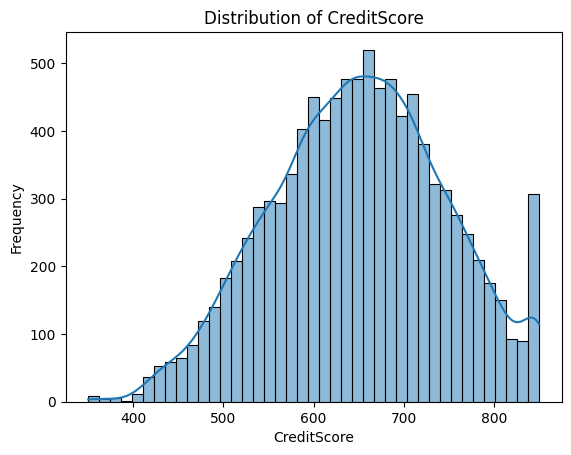

In [90]:
# Plotting the distribution of CreditScore
sns.histplot(df['CreditScore'], kde=True)
plt.title('Distribution of CreditScore')
plt.xlabel('CreditScore')
plt.ylabel('Frequency')
plt.show()

In [91]:
# Age column distribution
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

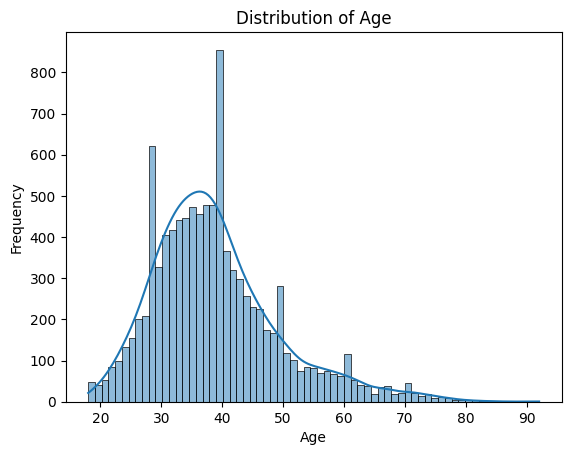

In [92]:
# Plot the distribution of Age
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [93]:
# Tenure column distribution
df['Tenure'].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

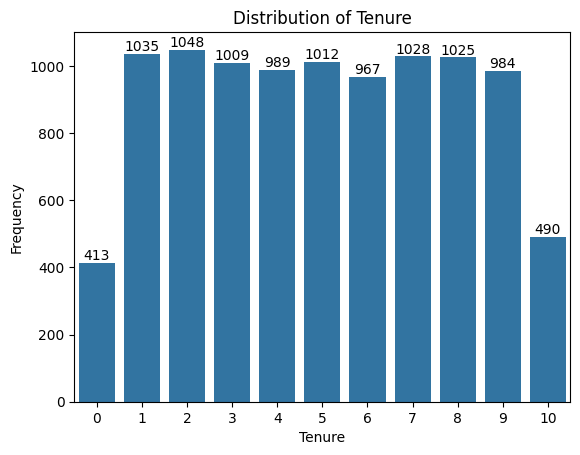

In [94]:
# Plotting the distribution of Tenure
ax = sns.countplot(x=df['Tenure'])
ax.bar_label(ax.containers[0])
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.show()

In [95]:
# Balance Column distribution
df['Balance'].value_counts()

Balance
0.00         3617
130170.82       2
105473.74       2
113957.01       1
85311.70        1
             ... 
88381.21        1
155060.41       1
57369.61        1
75075.31        1
116363.37       1
Name: count, Length: 6382, dtype: int64

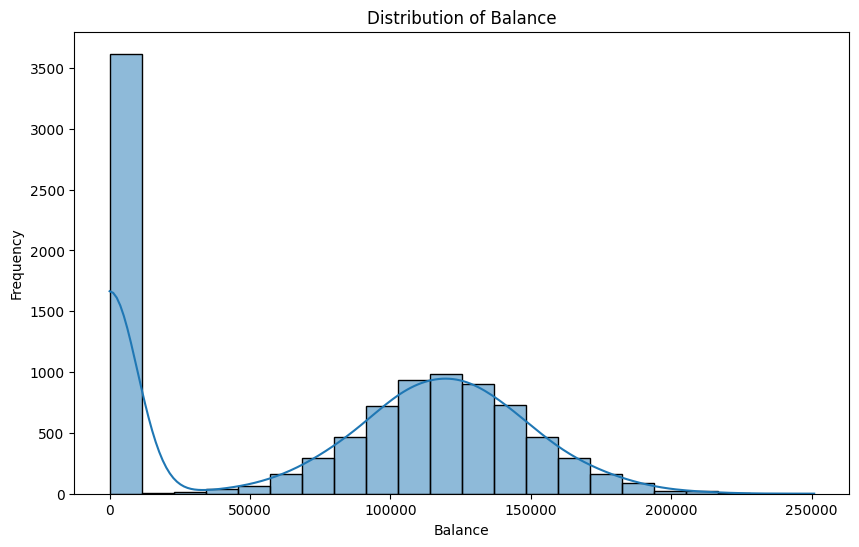

In [96]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Balance'], kde=True)
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

## Bivariate Analysis

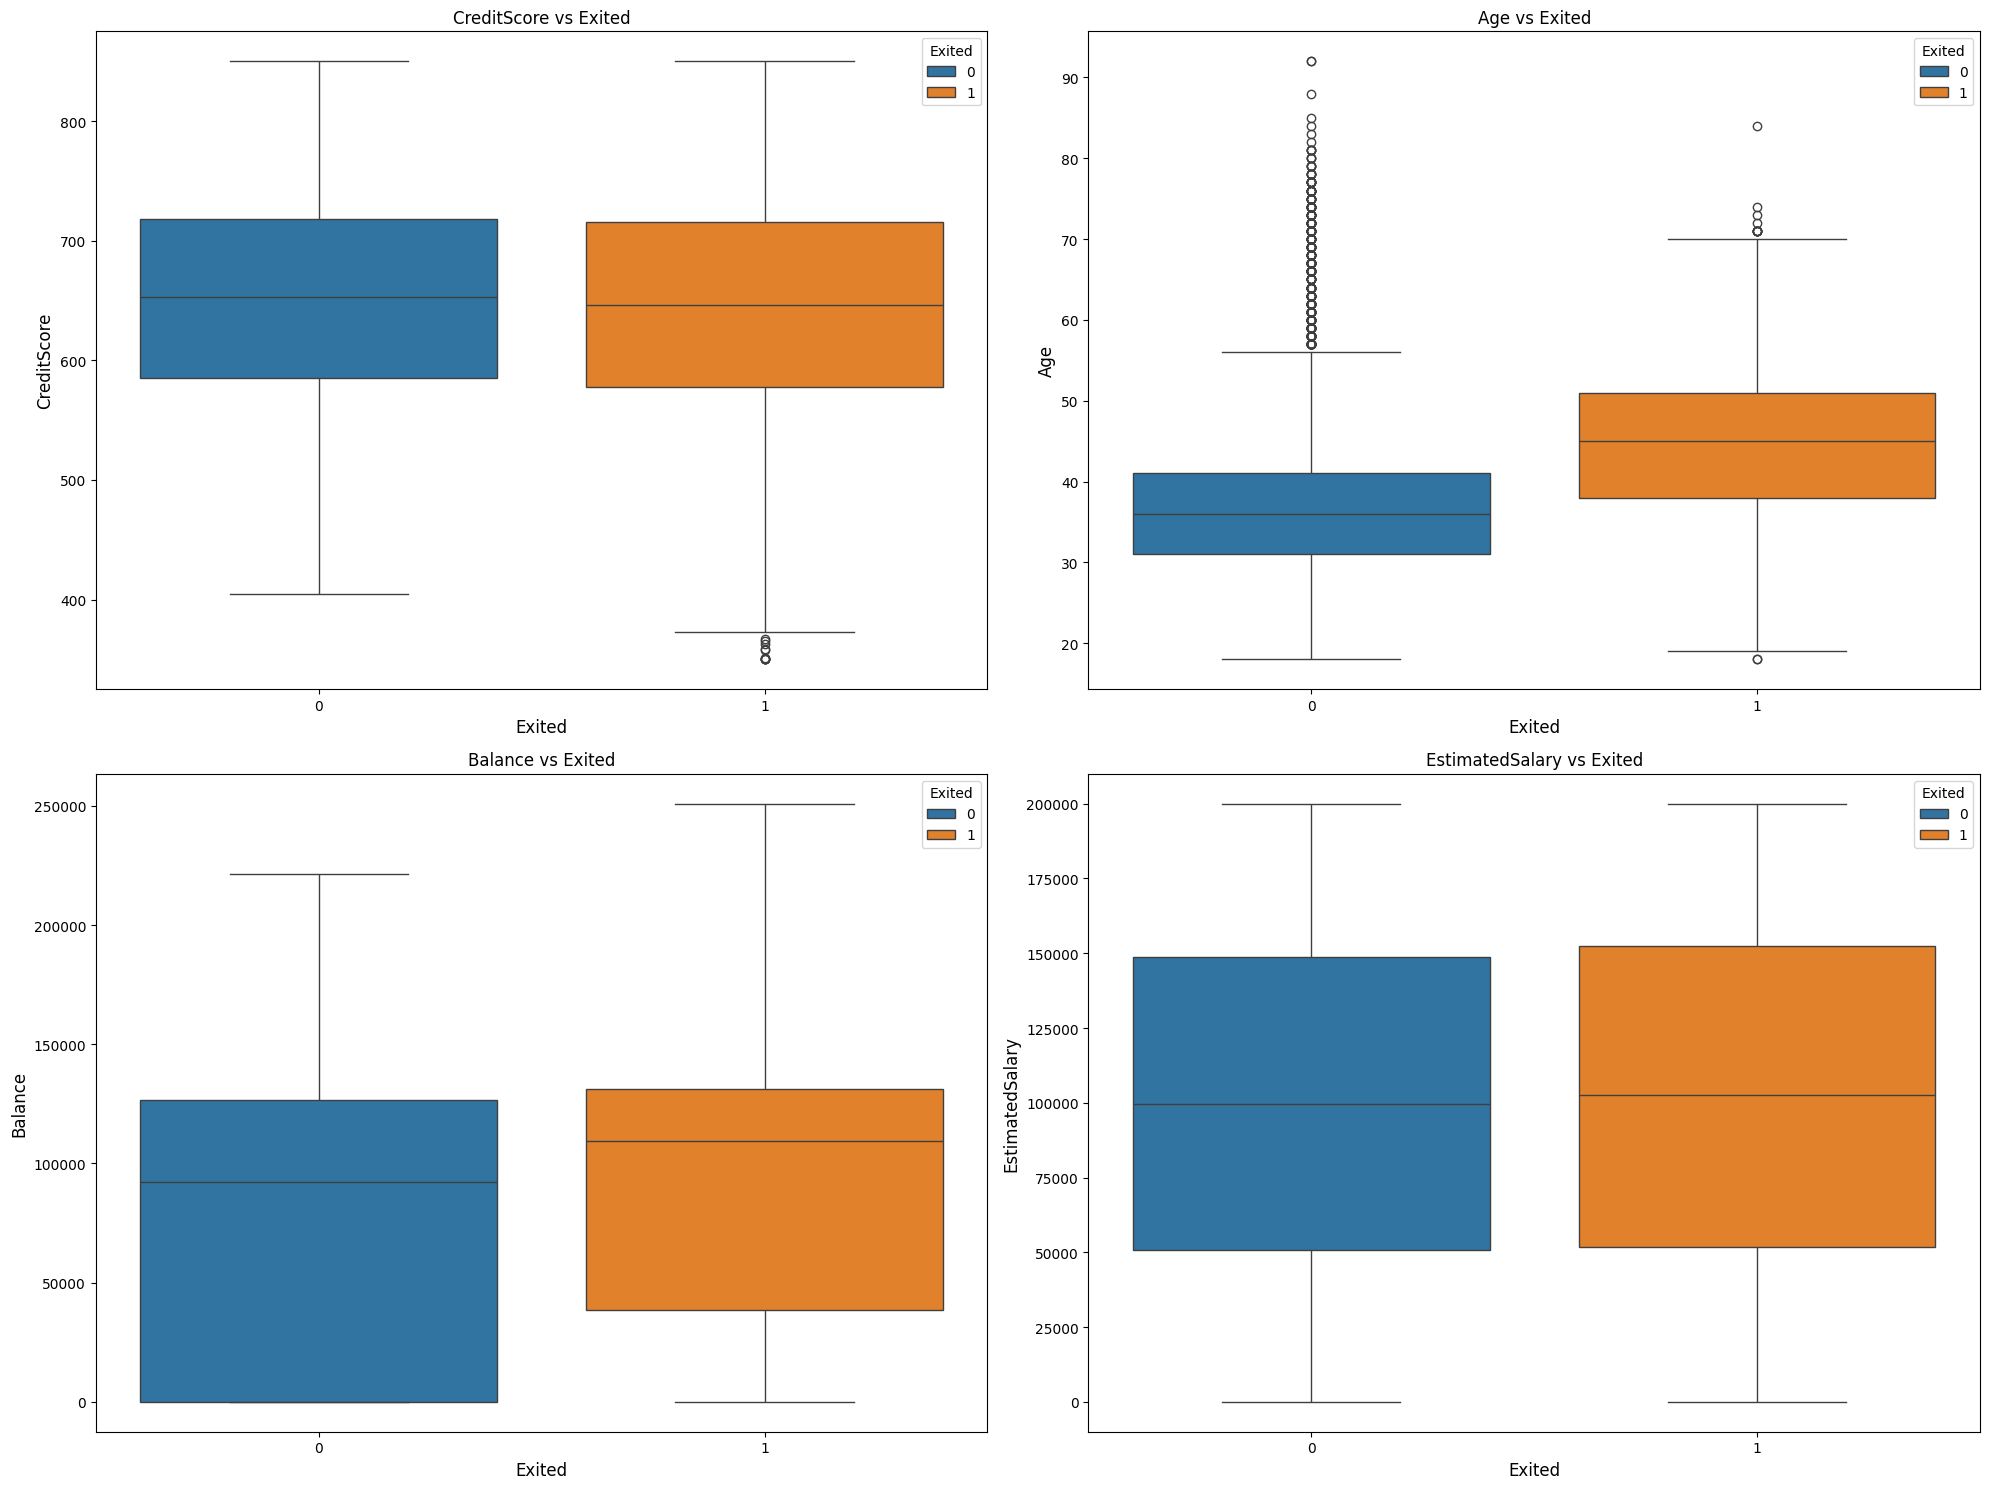

In [97]:
# Numerical features vs Target variable (Exited)
numerical_features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(20, 15))
for i, column in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df['Exited'], y=df[column], hue=df['Exited'])
    plt.title(f'{column} vs Exited')
    plt.xlabel('Exited', fontsize=12)
    plt.ylabel(column, fontsize=12)

plt.tight_layout()
plt.show()

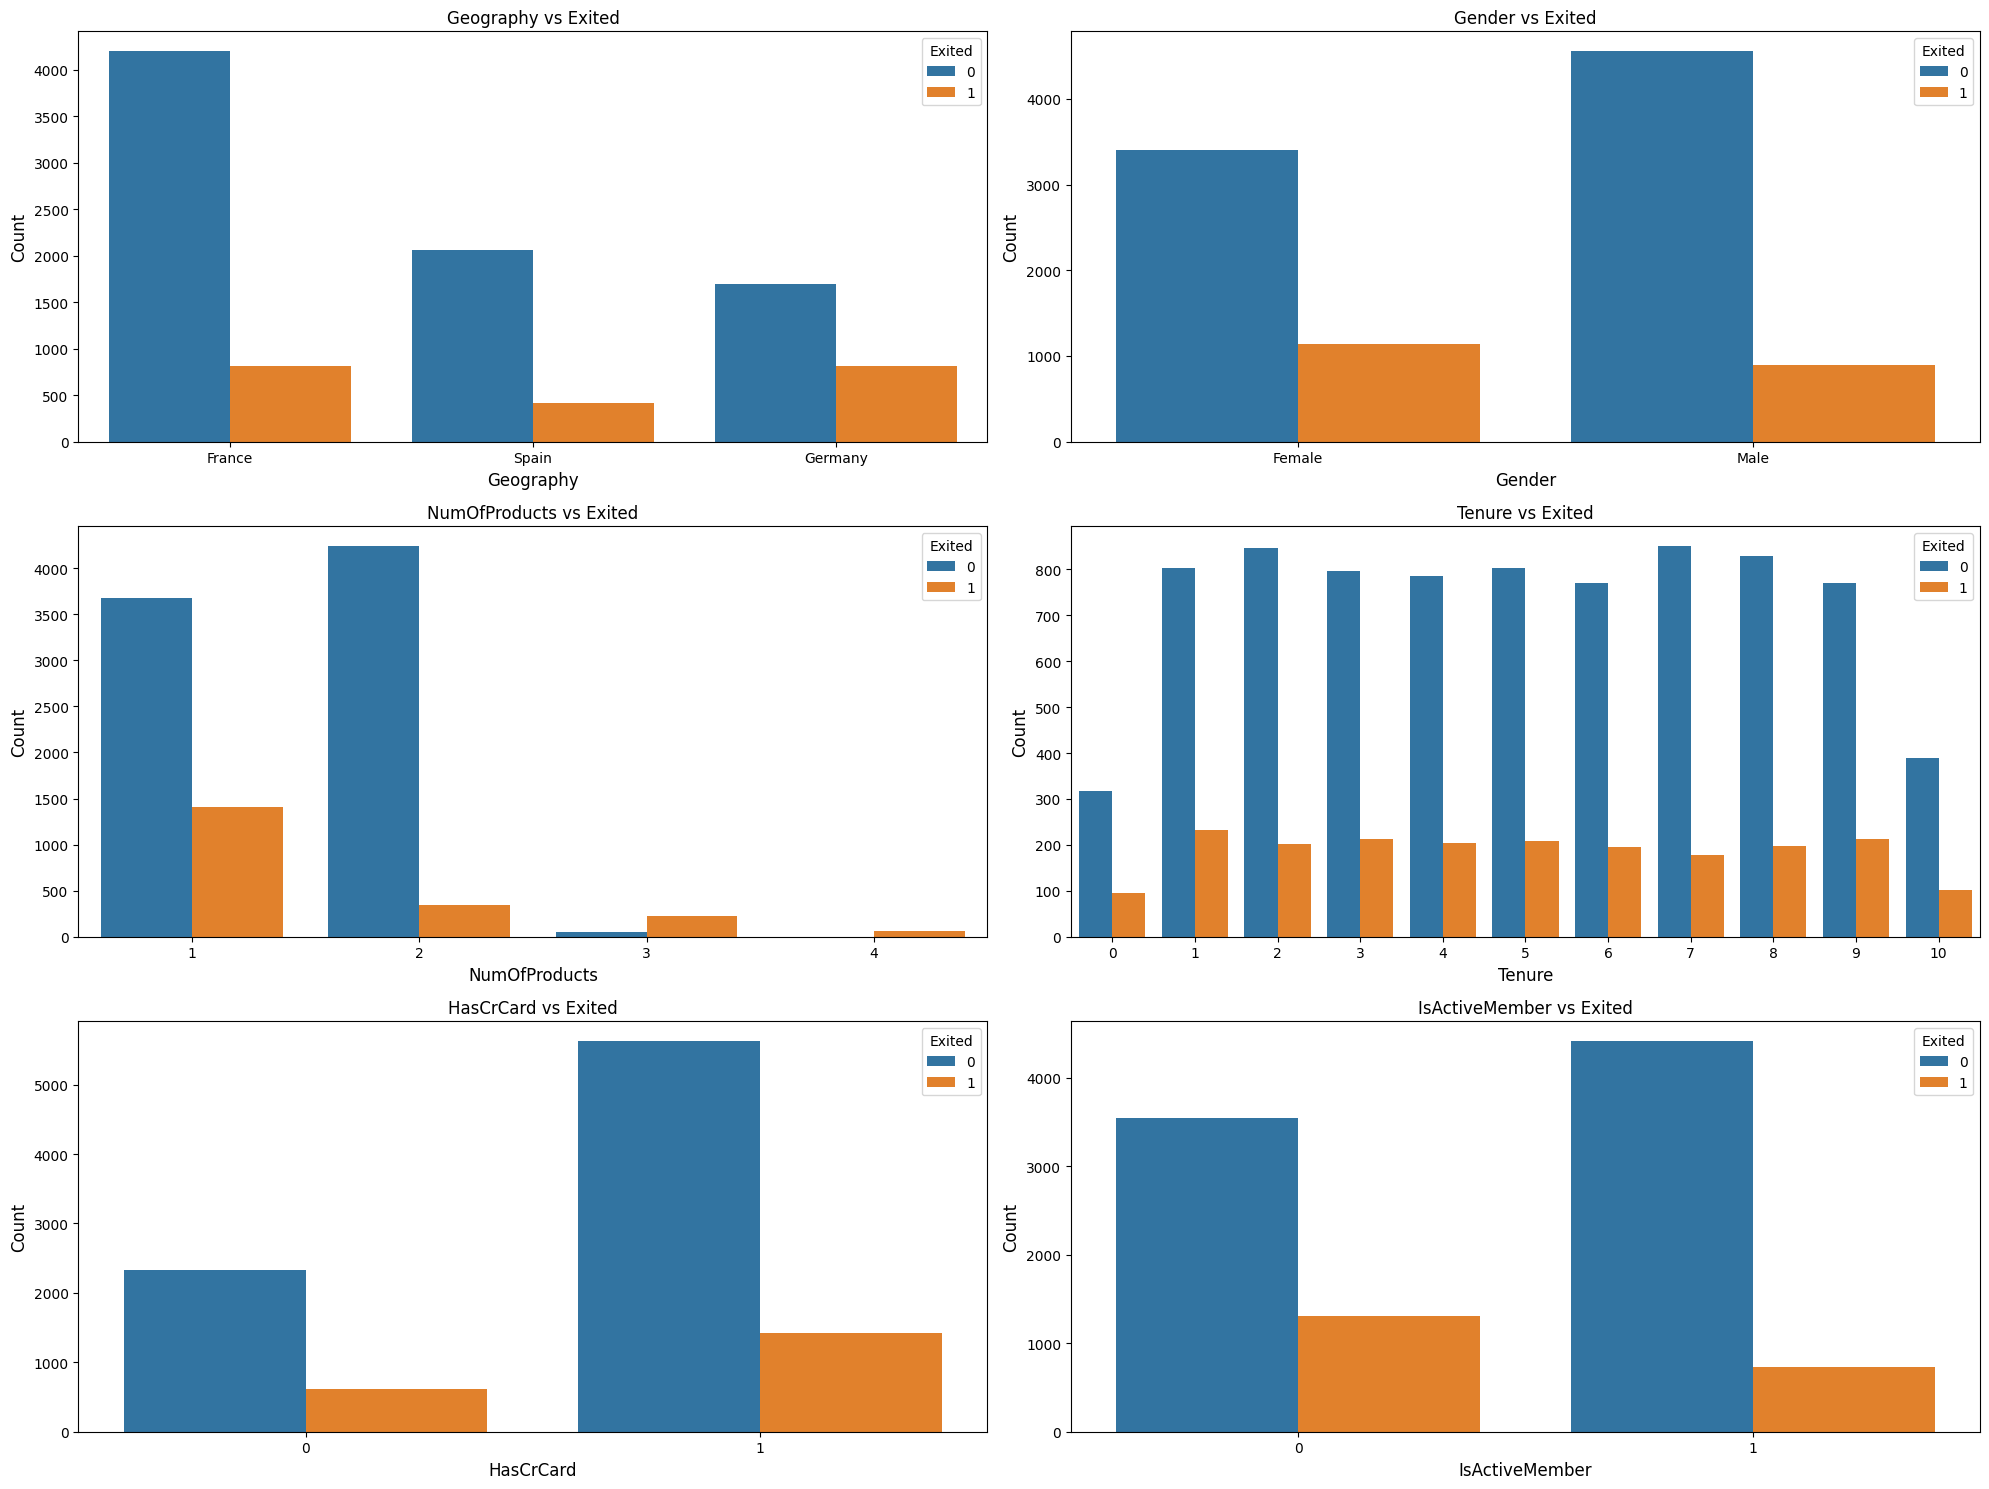

In [98]:
# Categorical features vs Target variable (Exited)
categorical_features = ['Geography', 'Gender', 'NumOfProducts','Tenure', 'HasCrCard', 'IsActiveMember']

plt.figure(figsize=(20, 15))
for i, column in enumerate(categorical_features):
    plt.subplot(3, 2, i + 1)
    sns.countplot(x=df[column], hue=df['Exited'])
    plt.title(f'{column} vs Exited')
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

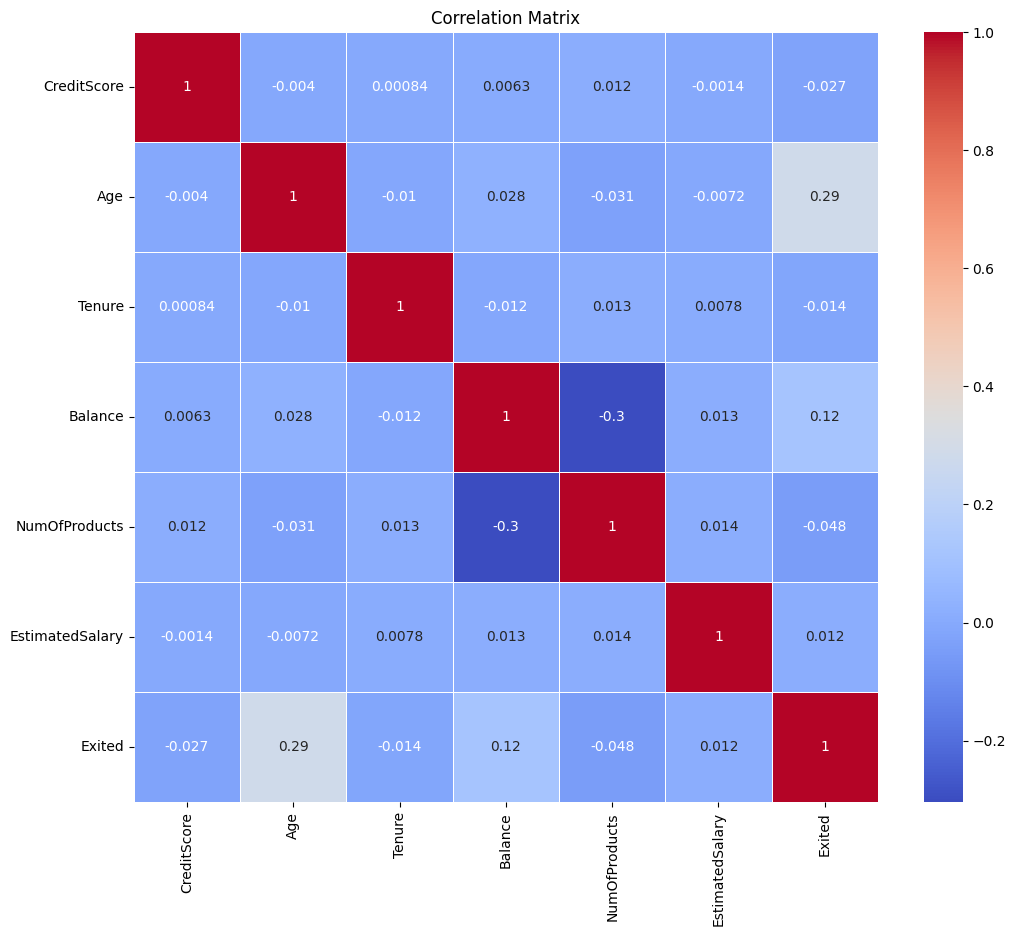

In [99]:
# Create conrelation matrix
plt.figure(figsize=(12, 10))
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Data Preprocessing

In [100]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [101]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Define Feature and Target

In [102]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [103]:
x

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [104]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [105]:
# Encoding categorical variables
x = pd.get_dummies(x, columns=['Geography', 'Gender'],
drop_first=True)
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [106]:
# Scaling numerical features
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

scaler = StandardScaler()

x[numerical_features] = scaler.fit_transform(x[numerical_features])

In [107]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,1,1,1,0.021886,False,False,False
1,-0.440036,0.198164,-1.387538,0.117350,1,0,1,0.216534,False,True,False
2,-1.536794,0.293517,1.032908,1.333053,3,1,0,0.240687,False,False,False
3,0.501521,0.007457,-1.387538,-1.225848,2,0,0,-0.108918,False,False,False
4,2.063884,0.388871,-1.041760,0.785728,1,1,1,-0.365276,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,1.246488,0.007457,-0.004426,-1.225848,2,1,0,-0.066419,False,False,True
9996,-1.391939,-0.373958,1.724464,-0.306379,1,1,1,0.027988,False,False,True
9997,0.604988,-0.278604,0.687130,-1.225848,1,0,1,-1.008643,False,False,False
9998,1.256835,0.293517,-0.695982,-0.022608,2,1,0,-0.125231,True,False,True
